# CURB - Chronic-Offender Intelligence
### notebook 03 - Problem Statement 1 (Parking-Induced Congestion)

Two data-grounded views that add a layer no other team is likely to have:

1. **Repeat-offender vehicles** - anonymized vehicle IDs cited 2+ times: how often,
   where, and whether they're *Habitual* (same spot) or *Roaming* (many spots).
2. **Recidivist locations** - spots where the **same** vehicles keep returning. A spot
   with 500 citations from 500 different cars is transient churn; 500 from 50 returning
   cars is a habitual-parking problem that needs a structural fix, not just a patrol.

**Honesty (put on the methodology slide):** these are repeat *detections*, not proven
repeat *offences* - a car caught often may simply park where enforcement is heavy. Treat
as candidates for review, not a verdict. Vehicle IDs are anonymized (aggregate targeting,
never owner identification). Everything traces to the provided dataset only.

In [1]:
import os, sys, json
from pathlib import Path
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "config.py").exists() and (REPO_ROOT.parent / "config.py").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT)); os.chdir(REPO_ROOT)
import config, pandas as pd, matplotlib.pyplot as plt
from src.offenders import run
DATA_PATH = config.DATA_PATH
pd.set_option("display.max_colwidth", 34)
print("data:", DATA_PATH, "exists:", os.path.exists(DATA_PATH))

data: data/violations.csv exists: True


## 1 - Run the analysis

In [2]:
veh, loc = run(DATA_PATH)
print(f"{len(veh):,} repeat-offender vehicles  |  {len(loc):,} locations assessed for recidivism")

[data] loaded 298,450 rows -> 248,376 usable after cleaning
27,971 repeat-offender vehicles  |  2,133 locations assessed for recidivism


## 2 - Repeat-offender vehicles

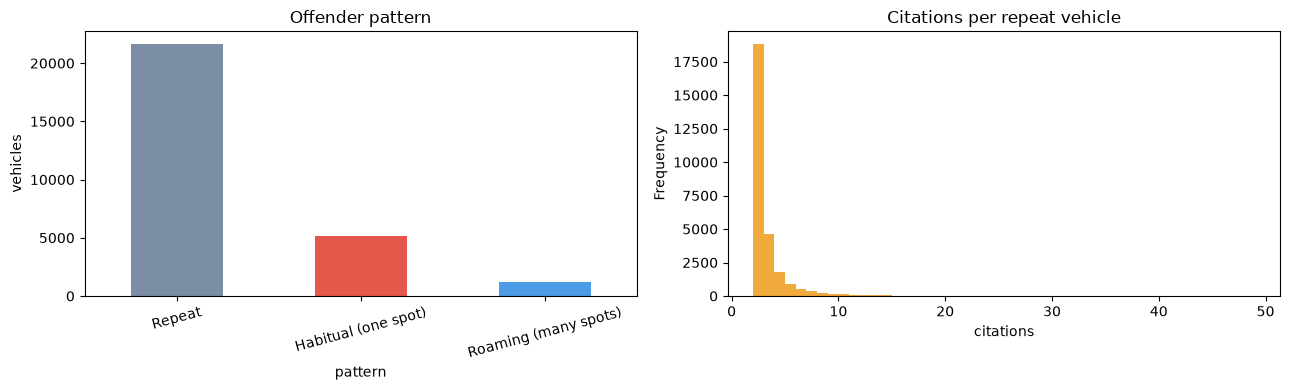

,violations,distinct_locations,top_location,top_location_share,span_days,vehicle_type,pattern
0,47,9,"Sahakar Nagar Road, Fortuna A...",0.45,135,SCOOTER,Roaming (many spots)
1,37,7,BTP058 - Subbanna Junction,0.46,146,CAR,Roaming (many spots)
2,33,4,BTP040 - Elite Junction,0.82,116,CAR,Habitual (one spot)
3,31,7,"New Horizon College Road, New...",0.61,99,SCOOTER,Habitual (one spot)
4,30,5,BTP051 - Safina Plaza Junction,0.83,92,SCOOTER,Habitual (one spot)
5,28,7,BTP040 - Elite Junction,0.39,144,MOTOR CYCLE,Roaming (many spots)
6,28,6,BTP051 - Safina Plaza Junction,0.57,124,PASSENGER AUTO,Roaming (many spots)
7,28,7,"BTP170 - Dr. Bheem Rao Palace,...",0.61,116,CAR,Habitual (one spot)
8,27,6,BTP051 - Safina Plaza Junction,0.74,118,MOTOR CYCLE,Habitual (one spot)
9,26,7,"BTP026 - 1st Block Junction, R...",0.35,131,CAR,Roaming (many spots)


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
veh["pattern"].value_counts().plot.bar(ax=ax[0], color=["#7C8DA6","#E5564B","#4C9BE6"])
ax[0].set_title("Offender pattern"); ax[0].set_ylabel("vehicles"); ax[0].tick_params(axis="x", rotation=15)
veh["violations"].plot.hist(bins=range(2, 50), ax=ax[1], color="#F0A93B")
ax[1].set_title("Citations per repeat vehicle"); ax[1].set_xlabel("citations")
plt.tight_layout(); plt.show()

veh.head(12)[["violations","distinct_locations","top_location","top_location_share",
              "span_days","vehicle_type","pattern"]]

The *Habitual (one spot)* vehicles are the most actionable: a plate cited many times
with a high `top_location_share` is parking illegally in the same place repeatedly - a
clean candidate for a targeted notice.

In [4]:
hab = veh[veh.pattern == "Habitual (one spot)"].head(10)
hab[["violations","top_location","top_location_share","vehicle_type","span_days"]]

,violations,top_location,top_location_share,vehicle_type,span_days
2,33,BTP040 - Elite Junction,0.82,CAR,116
3,31,"New Horizon College Road, New...",0.61,SCOOTER,99
4,30,BTP051 - Safina Plaza Junction,0.83,SCOOTER,92
7,28,"BTP170 - Dr. Bheem Rao Palace,...",0.61,CAR,116
8,27,BTP051 - Safina Plaza Junction,0.74,MOTOR CYCLE,118
12,25,BTP040 - Elite Junction,0.76,MOTOR CYCLE,62
13,23,BTP040 - Elite Junction,0.61,SCOOTER,142
14,23,BTP058 - Subbanna Junction,0.65,CAR,147
17,23,BTP042 - Minsk Square Junction...,0.83,SCOOTER,80
20,22,"Bhadrappa Flyover, Nagashetty...",0.64,MOTOR CYCLE,135


## 3 - Recidivist locations (same vehicles returning)

recidivism
Transient    1657
Mixed         413
Habitual       63


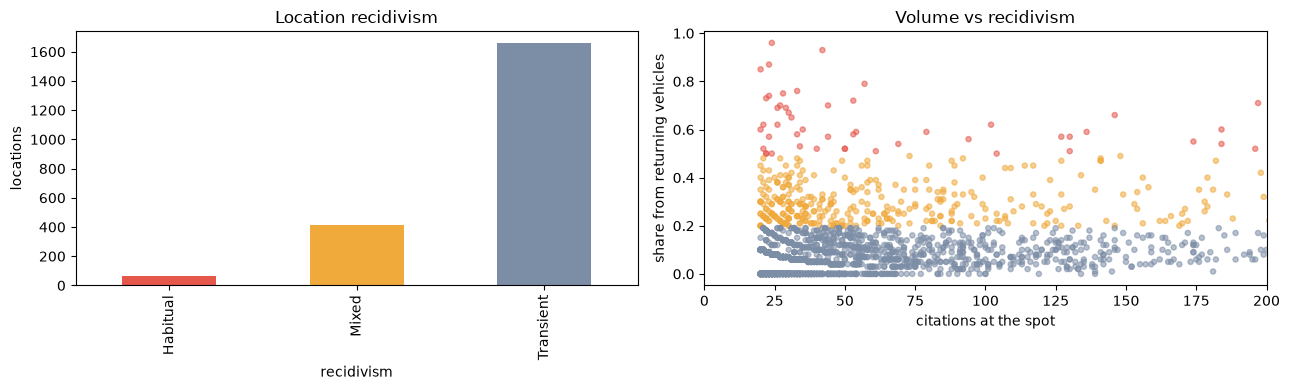

In [5]:
print(loc.recidivism.value_counts().to_string())
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
loc.recidivism.value_counts().reindex(["Habitual","Mixed","Transient"]).plot.bar(
    ax=ax[0], color=["#E5564B","#F0A93B","#7C8DA6"])
ax[0].set_title("Location recidivism"); ax[0].set_ylabel("locations")
col = loc.recidivism.map({"Habitual":"#E5564B","Mixed":"#F0A93B","Transient":"#7C8DA6"})
ax[1].scatter(loc.violations, loc.repeat_share, s=14, c=col, alpha=.55)
ax[1].set_xlabel("citations at the spot"); ax[1].set_ylabel("share from returning vehicles")
ax[1].set_title("Volume vs recidivism"); ax[1].set_xlim(0, 200)
plt.tight_layout(); plt.show()

In [6]:
loc.head(12)[["rank","name","violations","distinct_vehicles","repeat_vehicles",
              "repeat_share","recidivism","impact_score"]]

,rank,name,violations,distinct_vehicles,repeat_vehicles,repeat_share,recidivism,impact_score
0,1,"1st Main Road, Jayamahal Exte...",24,12,11,0.96,Habitual,36.6
1,2,"Panathur Main Road, Mariyappa...",42,12,9,0.93,Habitual,210.0
2,3,"Parappana Agrahara Main Road, ...",23,8,5,0.87,Habitual,22.8
3,4,Siddavanahalli Krishna Sharma ...,20,7,4,0.85,Habitual,29.0
4,5,"Outer Ring Road, Vajram Onyx",57,17,5,0.79,Habitual,224.6
5,6,"Palace Road, MD Nanjundaswamy...",33,16,8,0.76,Habitual,22.0
6,7,"Thanisandra Main Road, Aswath...",28,14,7,0.75,Habitual,19.4
7,8,"4th Main Road, Malleshwara Ex...",23,12,6,0.74,Habitual,14.6
8,9,"Brigade Road, ACR Towers",22,10,4,0.73,Habitual,16.4
9,10,"Hosa Road, Channakeshava Nagar",53,20,5,0.72,Habitual,43.4


A **Habitual** location (high `repeat_share`, few distinct vehicles) argues for a
*structural* response - designated/permit parking - because the same vehicles return
daily. A **Transient** spot (many different vehicles) argues for *enforcement presence*.
This sharpens the root-cause prescription from notebook 02.

## 4 - Files written (for the deck / optional frontend use)

In [ ]:
for f in ["outputs/curb_offenders.json","outputs/curb_offender_vehicles.csv","outputs/curb_recidivist_locations.csv"]:
    print("wrote", f, "-", os.path.getsize(f), "bytes")
j = json.load(open("outputs/curb_offenders.json"))
print("\nmeta:", json.dumps(j["meta"], indent=2))
print("\nsample recidivist location:"); print(json.dumps(j["recidivist_locations"][0], indent=2))

wrote outputs/curb_offenders.json - 192890 bytes
wrote outputs/curb_offender_vehicles.csv - 2336760 bytes
wrote outputs/curb_recidivist_locations.csv - 181047 bytes

meta: {
  "repeat_offender_vehicles": 27971,
  "recidivist_locations_assessed": 2133,
  "note": "Repeat DETECTIONS, not proven repeat offences; anonymized vehicle IDs; provided dataset only."
}

sample recidivist location:
{
  "rank": 1,
  "name": "1st Main Road,  Jayamahal Extension",
  "lat": 12.9995,
  "lon": 77.597,
  "violations": 24,
  "distinct_vehicles": 12,
  "repeat_vehicles": 11,
  "repeat_share": 0.96,
  "recidivism": "Habitual",
  "impact_score": 36.6
}


: 

## Methodology note
- Repeat **detections**, not proven offences (enforcement-location bias acknowledged).
- Anonymized vehicle IDs -> aggregate targeting only, never owner identification.
- A location is assessed for recidivism only if it has >= 20 citations (below that, a
  "100% repeat" is just noise). Thresholds are documented constants in `src/offenders.py`.
- Provided dataset only; no external data.